In [1]:
from pathlib import Path
import pandas as pd

# Use repo-relative `pr` directory (Windows)
print("cwd:", Path.cwd())
base_path = Path("pr")
print("resolved:", base_path.resolve())
print("exists:", base_path.exists())

records = []
if base_path.exists():
    for f in sorted(base_path.rglob("*")):
        if not f.is_file():
            continue

        read_ok = True
        detail = "ok"
        n_rows = None
        n_cols = None

        try:
            ext = f.suffix.lower()

            if ext == ".csv":
                df_tmp = pd.read_csv(f)
                n_rows, n_cols = df_tmp.shape
            elif ext in [".tsv", ".txt"]:
                df_tmp = pd.read_csv(f, sep="\t")
                n_rows, n_cols = df_tmp.shape
            elif ext == ".json":
                df_tmp = pd.read_json(f)
                n_rows, n_cols = df_tmp.shape
            elif ext == ".parquet":
                df_tmp = pd.read_parquet(f)
                n_rows, n_cols = df_tmp.shape
            elif ext in [".xlsx", ".xls"]:
                df_tmp = pd.read_excel(f)
                n_rows, n_cols = df_tmp.shape
            else:
                # Validación básica de lectura para otros tipos
                with open(f, "rb") as fh:
                    _ = fh.read(1024)

        except Exception as e:
            read_ok = False
            detail = str(e)

        records.append(
            {
                "file_name": f.name,
                "file_path": str(f),
                "size_bytes": f.stat().st_size,
                "read_ok": read_ok,
                "rows": n_rows,
                "cols": n_cols,
                "detail": detail,
            }
        )
else:
    print(f"No existe la ruta: {base_path}")

df_files = pd.DataFrame(records)

cwd: c:\Users\elxpa\Documents\GitHub\TESIS
resolved: C:\Users\elxpa\Documents\GitHub\TESIS\pr
exists: True


Archivos encontrados: 672


C:\Users\elxpa\AppData\Local\Temp\ipykernel_19712\3726044609.py:16: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


Region seleccionada: La Araucanía
Limites del poligono: lon [-73.955, -70.834] | lat [-39.747, -37.633]
Grilla recortada: 42 lat x 62 lon
Pixeles CR2MET dentro de La Araucanía: 1401


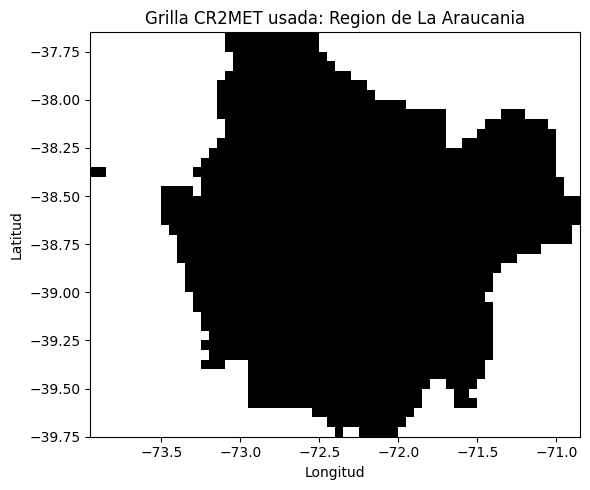

In [2]:
# Cargar dataset CR2MET y seleccionar toda la grilla de la Region de La Araucania
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point
from shapely.prepared import prep
from pathlib import Path

pr_dir = Path("pr")
files = sorted(pr_dir.glob("CR2MET_pr_v2.5_day_*.nc"))
print("Archivos encontrados:", len(files))
if not files:
    raise RuntimeError("No se encontraron archivos CR2MET en pr/")

ds = xr.open_mfdataset(
    [str(p) for p in files],
    combine="by_coords",
    parallel=True,
    chunks={"time": 365},
)

reader = shpreader.Reader(
    shpreader.natural_earth(
        resolution="10m",
        category="cultural",
        name="admin_1_states_provinces",
    )
)
region_record = next(
    r for r in reader.records()
    if r.attributes.get("admin") == "Chile" and "Arauc" in str(r.attributes.get("name"))
)
region_name = region_record.attributes["name"]
region_geom = region_record.geometry

min_lon, min_lat, max_lon, max_lat = region_geom.bounds
lat_slice = slice(max_lat, min_lat) if ds.lat[0] > ds.lat[-1] else slice(min_lat, max_lat)
lon_slice = slice(min_lon, max_lon) if ds.lon[0] < ds.lon[-1] else slice(max_lon, min_lon)

pr_region = ds["pr"].sel(lat=lat_slice, lon=lon_slice)
lon2d, lat2d = np.meshgrid(pr_region["lon"].values, pr_region["lat"].values)
prepared_geom = prep(region_geom)

region_mask = np.array(
    [
        prepared_geom.contains(Point(lon, lat)) or region_geom.touches(Point(lon, lat))
        for lat, lon in zip(lat2d.ravel(), lon2d.ravel())
    ],
    dtype=bool,
).reshape(lat2d.shape)

region_mask_da = xr.DataArray(
    region_mask,
    coords={"lat": pr_region["lat"], "lon": pr_region["lon"]},
    dims=("lat", "lon"),
)

pr_region = pr_region.where(region_mask_da)

print(f"Region seleccionada: {region_name}")
print(f"Limites del poligono: lon [{min_lon:.3f}, {max_lon:.3f}] | lat [{min_lat:.3f}, {max_lat:.3f}]")
print(f"Grilla recortada: {pr_region.sizes['lat']} lat x {pr_region.sizes['lon']} lon")
print(f"Pixeles CR2MET dentro de {region_name}: {int(region_mask.sum())}")

plt.figure(figsize=(6, 5))
plt.pcolormesh(pr_region["lon"], pr_region["lat"], region_mask.astype(int), shading="auto", cmap="Greys")
plt.title("Grilla CR2MET usada: Region de La Araucania")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()


In [3]:
# Recortar al periodo de estudio y cargar a memoria solo la region seleccionada
import pandas as pd

pr_region = pr_region.sel(time=slice("1979-01-01", "2021-12-31")).load()
dry_threshold_mm = 1.0

p1_region = pr_region.sel(time=slice("1979-01-01", "2000-12-31"))
p2_region = pr_region.sel(time=slice("2001-01-01", "2021-12-31"))

print(
    "Periodo total:",
    str(pd.to_datetime(pr_region["time"].values[0]).date()),
    "a",
    str(pd.to_datetime(pr_region["time"].values[-1]).date()),
)
print("Forma del arreglo regional:", pr_region.shape)
print("Umbral de dia seco:", dry_threshold_mm, "mm/dia")


Periodo total: 1979-01-01 a 2021-12-31
Forma del arreglo regional: (15706, 42, 62)
Umbral de dia seco: 1.0 mm/dia


In [4]:
import numpy as np
import pandas as pd

def dry_spells_from_bool(time_index, dry_bool, min_len=1):
    dry = np.asarray(dry_bool, dtype=bool)

    x = np.r_[False, dry, False]
    dx = np.diff(x.astype(int))

    starts = np.where(dx == 1)[0]
    ends_excl = np.where(dx == -1)[0]
    lengths = ends_excl - starts

    mask = lengths >= min_len
    starts = starts[mask]
    ends_excl = ends_excl[mask]
    lengths = lengths[mask]

    t = np.asarray(time_index)
    start_dates = t[starts]
    end_dates = t[ends_excl - 1]

    df = pd.DataFrame({
        "start": pd.to_datetime(start_dates),
        "end": pd.to_datetime(end_dates),
        "duration_days": lengths.astype(int),
    }).sort_values("start").reset_index(drop=True)

    return df


def extract_regional_spells(data_array, dry_threshold=1.0, min_len=1):
    vals = data_array.values
    times = pd.to_datetime(data_array["time"].values)
    years = times.year

    all_years = []
    all_durations = []

    for i in range(vals.shape[1]):
        for j in range(vals.shape[2]):
            pr_series = vals[:, i, j]
            if np.isnan(pr_series).all():
                continue

            dry_bool = pr_series < dry_threshold
            x = np.r_[False, dry_bool, False]
            dx = np.diff(x.astype(int))

            starts = np.where(dx == 1)[0]
            ends_excl = np.where(dx == -1)[0]
            lengths = ends_excl - starts

            mask = lengths >= min_len
            starts = starts[mask]
            lengths = lengths[mask]

            if len(lengths) == 0:
                continue

            all_years.extend(years[starts].tolist())
            all_durations.extend(lengths.astype(int).tolist())

    return pd.DataFrame({
        "year": np.asarray(all_years, dtype=int),
        "duration_days": np.asarray(all_durations, dtype=int),
    })


def compute_pdf_and_fit(data, n_bins=30):
    data = np.asarray(data)
    data = data[data > 0]
    if len(data) == 0:
        return None

    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), n_bins)
    counts, bin_edges = np.histogram(data, bins=bins)
    if counts.sum() == 0:
        return None

    bin_widths = np.diff(bin_edges)
    pdf = counts / counts.sum() / bin_widths
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

    valid = pdf > 0
    if valid.sum() < 3:
        return None

    x_val = bin_centers[valid]
    y_val = pdf[valid]

    Y = np.log(y_val)
    X_matrix = np.column_stack((np.ones(len(x_val)), np.log(x_val), x_val))
    c, residuals, rank, s = np.linalg.lstsq(X_matrix, Y, rcond=None)
    c1, c2, c3 = c

    tau = -c2
    tL = -1.0 / c3 if c3 < 0 else np.inf
    A_fit = np.exp(c1)

    return {
        "x": x_val,
        "y": y_val,
        "tau": tau,
        "tL": tL,
        "A": A_fit,
        "bins": bin_edges,
    }


def get_fit_parameters(data, n_bins=30):
    fit = compute_pdf_and_fit(data, n_bins=n_bins)
    if fit is None:
        return np.nan, np.nan
    return fit["tau"], fit["tL"]


Total dry spells en La Araucanía (1979-2021): 2809335
Total dry spells en 1979-2000: 1417527
Total dry spells en 2001-2021: 1391808

Numero de dry spells por anio (anio de inicio de la racha):
      n_dry_spells
year              
1979         51412
1980         67075
1981         71154
1982         58994
1983         55819
1984         74064
1985         66007
1986         69863
1987         62319
1988         56603
1989         69634
1990         67979
1991         67008
1992         74797
1993         62359
1994         65185
1995         57270
1996         66061
1997         57247
1998         59664
1999         64559
2000         72454
2001         62964
2002         72246
2003         68244
2004         64652
2005         56599
2006         68672
2007         68193
2008         59470
2009         64113
2010         67780
2011         73130
2012         68481
2013         69557
2014         63471
2015         57807
2016         67886
2017         76710
2018         75140
2019     

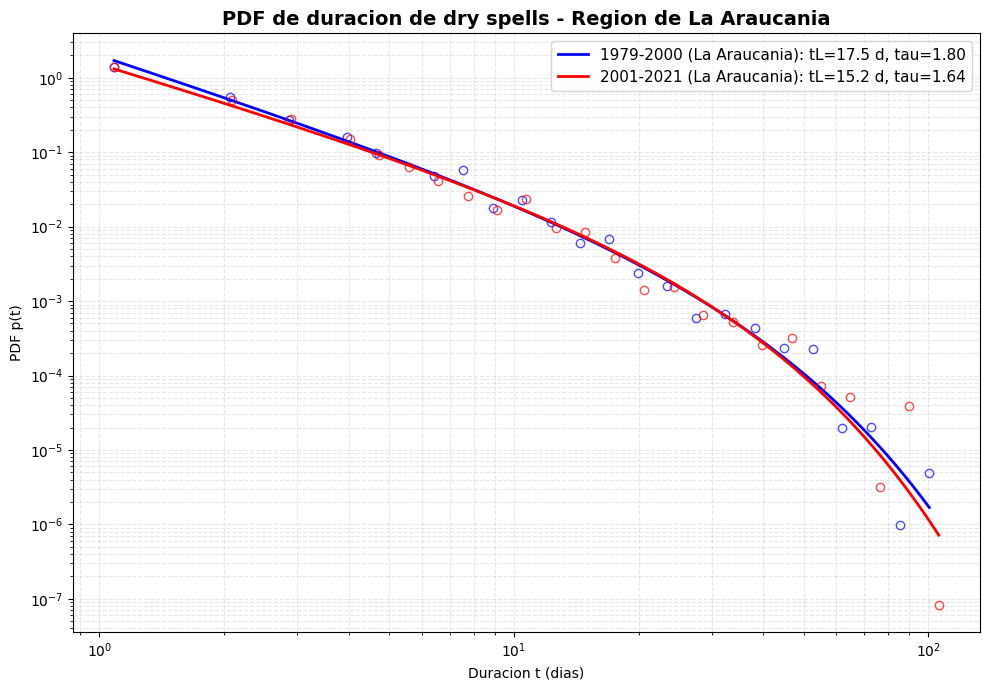

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extraer todas las rachas secas de toda la Region de La Araucania
# Cada racha se asigna al anio en que comienza
# (si cruza dos anios, se cuenta por su anio de inicio)
df_spells_region = extract_regional_spells(
    pr_region,
    dry_threshold=dry_threshold_mm,
    min_len=1,
)

df_p1 = df_spells_region[df_spells_region["year"] <= 2000].copy()
df_p2 = df_spells_region[df_spells_region["year"] > 2000].copy()

dur_p1_reg = df_p1["duration_days"].to_numpy()
dur_p2_reg = df_p2["duration_days"].to_numpy()

spells_by_year = {
    int(year): group["duration_days"].to_numpy(dtype=np.int16)
    for year, group in df_spells_region.groupby("year")
}

counts_by_year = (
    df_spells_region.groupby("year")
    .size()
    .rename("n_dry_spells")
    .to_frame()
)

print(f"Total dry spells en {region_name} (1979-2021): {len(df_spells_region)}")
print(f"Total dry spells en 1979-2000: {len(df_p1)}")
print(f"Total dry spells en 2001-2021: {len(df_p2)}")
print()
print("Numero de dry spells por anio (anio de inicio de la racha):")
print(counts_by_year.to_string())

periodos = [
    {"data": dur_p1_reg, "label": "1979-2000 (La Araucania)", "color": "blue"},
    {"data": dur_p2_reg, "label": "2001-2021 (La Araucania)", "color": "red"},
]

plt.figure(figsize=(10, 7))

for p in periodos:
    fit = compute_pdf_and_fit(p["data"], n_bins=30)
    if fit is None:
        continue

    t_range = np.logspace(np.log10(fit["x"].min()), np.log10(fit["x"].max()), 200)
    fit_curve = fit["A"] * (t_range ** (-fit["tau"])) * np.exp(-t_range / fit["tL"])

    plt.loglog(fit["x"], fit["y"], "o", color=p["color"], mfc="none", alpha=0.7)
    tL_str = f"{fit['tL']:.1f} d" if np.isfinite(fit["tL"]) else "inf"
    plt.plot(
        t_range,
        fit_curve,
        color=p["color"],
        lw=2,
        label=f"{p['label']}: tL={tL_str}, tau={fit['tau']:.2f}",
    )

plt.title("PDF de duracion de dry spells - Region de La Araucania", fontsize=14, fontweight="bold")
plt.xlabel("Duracion t (dias)")
plt.ylabel("PDF p(t)")
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()
plt.show()


## Numero de dry spells por periodo

En este notebook el conteo se hace usando el anio de inicio de cada `dry spell`.
Los totales impresos arriba corresponden a toda la grilla CR2MET dentro de la Region de La Araucania.


## Bootstrapping por anos

Aqui el remuestreo ya no se hace sobre `dry spells` individuales.
Primero se separan todos los `dry spells` por anio de inicio. Luego, para cada periodo, se sortean anos completos con reemplazo:

- Para `1979-2000` se sortean `22` anos con reemplazo.
- Para `2001-2021` se sortean `21` anos con reemplazo.

Cada vez que un anio es elegido, entran juntos todos los `dry spells` de todos los pixeles de La Araucania que comenzaron en ese anio. Luego se reconstruye la PDF regional y se recalculan `tau` y `tL`.

Repetir eso muchas veces entrega una distribucion de valores posibles para `tau` y `tL` y permite estimar intervalos de confianza al `95%`.

Este enfoque sigue la sugerencia del profesor porque preserva mejor la dependencia temporal dentro de cada anio que remuestrear rachas secas una por una.


In [8]:
import numpy as np

years_p1 = np.sort(df_p1["year"].unique())
years_p2 = np.sort(df_p2["year"].unique())


def bootstrap_sample_by_year(years_available, spells_lookup, rng):
    sampled_years = rng.choice(years_available, size=len(years_available), replace=True)
    sampled_spells = np.concatenate([spells_lookup[int(year)] for year in sampled_years])
    return sampled_years, sampled_spells


n_iterations = 1000
rng = np.random.default_rng(42)

boot_tau_p1, boot_tL_p1 = [], []
boot_tau_p2, boot_tL_p2 = [], []

print("Calculando bootstrap por años (esto puede tomar alrededor de un minuto)...")

for _ in range(n_iterations):
    _, sample_p1 = bootstrap_sample_by_year(years_p1, spells_by_year, rng)
    _, sample_p2 = bootstrap_sample_by_year(years_p2, spells_by_year, rng)

    tau1, tL1 = get_fit_parameters(sample_p1, n_bins=30)
    tau2, tL2 = get_fit_parameters(sample_p2, n_bins=30)

    if np.isfinite(tau1) and np.isfinite(tL1):
        boot_tau_p1.append(tau1)
        boot_tL_p1.append(tL1)

    if np.isfinite(tau2) and np.isfinite(tL2):
        boot_tau_p2.append(tau2)
        boot_tL_p2.append(tL2)

tau_orig_p1, tL_orig_p1 = get_fit_parameters(dur_p1_reg, n_bins=30)
tau_orig_p2, tL_orig_p2 = get_fit_parameters(dur_p2_reg, n_bins=30)

print()
print("=== Resultados bootstrap por años (IC 95%) ===")
print("Periodo 1979-2000:")
print(f"  tau original: {tau_orig_p1:.3f}")
print(f"  tL original:  {tL_orig_p1:.3f} días")
print(f"  IC95 tau: [{np.percentile(boot_tau_p1, 2.5):.3f}, {np.percentile(boot_tau_p1, 97.5):.3f}]")
print(f"  IC95 tL:  [{np.percentile(boot_tL_p1, 2.5):.3f}, {np.percentile(boot_tL_p1, 97.5):.3f}] días")

print()
print("Periodo 2001-2021:")
print(f"  tau original: {tau_orig_p2:.3f}")
print(f"  tL original:  {tL_orig_p2:.3f} días")
print(f"  IC95 tau: [{np.percentile(boot_tau_p2, 2.5):.3f}, {np.percentile(boot_tau_p2, 97.5):.3f}]")
print(f"  IC95 tL:  [{np.percentile(boot_tL_p2, 2.5):.3f}, {np.percentile(boot_tL_p2, 97.5):.3f}] días")


Calculando bootstrap por anos (esto puede tomar alrededor de un minuto)...

=== Resultados bootstrap por años (IC 95%) ===
Periodo 1979-2000:
  tau original: 1.798
  tL original:  17.492 días
  IC95 tau: [1.594, 2.092]
  IC95 tL:  [13.365, 31.796] días

Periodo 2001-2021:
  tau original: 1.643
  tL original:  15.214 días
  IC95 tau: [1.135, 2.327]
  IC95 tL:  [8.335, 72.188] días


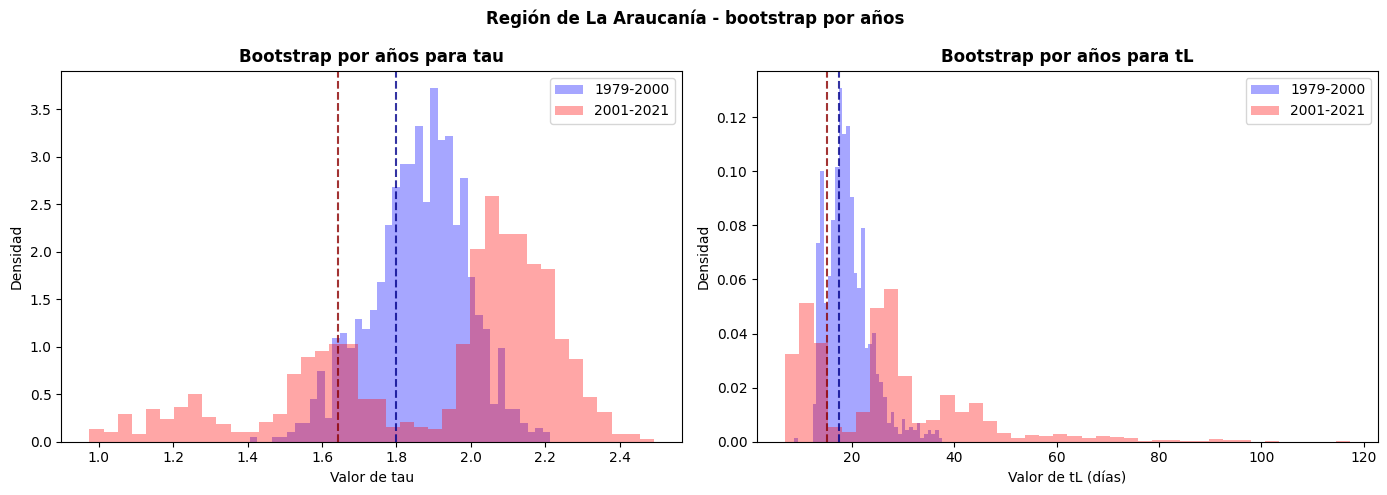

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(boot_tau_p1, bins=40, density=True, alpha=0.35, color="blue", label="1979-2000")
axes[0].hist(boot_tau_p2, bins=40, density=True, alpha=0.35, color="red", label="2001-2021")
axes[0].axvline(tau_orig_p1, color="darkblue", linestyle="--", alpha=0.8)
axes[0].axvline(tau_orig_p2, color="darkred", linestyle="--", alpha=0.8)
axes[0].set_title("Bootstrap por años para tau", fontweight="bold")
axes[0].set_xlabel("Valor de tau")
axes[0].set_ylabel("Densidad")
axes[0].legend()

tL_p1_filtered = [x for x in boot_tL_p1 if x < np.percentile(boot_tL_p1, 99.5)]
tL_p2_filtered = [x for x in boot_tL_p2 if x < np.percentile(boot_tL_p2, 99.5)]

axes[1].hist(tL_p1_filtered, bins=40, density=True, alpha=0.35, color="blue", label="1979-2000")
axes[1].hist(tL_p2_filtered, bins=40, density=True, alpha=0.35, color="red", label="2001-2021")
axes[1].axvline(tL_orig_p1, color="darkblue", linestyle="--", alpha=0.8)
axes[1].axvline(tL_orig_p2, color="darkred", linestyle="--", alpha=0.8)
axes[1].set_title("Bootstrap por años para tL", fontweight="bold")
axes[1].set_xlabel("Valor de tL (días)")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.suptitle("Región de La Araucanía - bootstrap por años", fontweight="bold")
plt.tight_layout()
plt.show()
